In [1]:
# Cargar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración para gráficos
sns.set(style="whitegrid", context="talk")

# Cargar los datos (asegúrate de que la ruta sea correcta)
file_path = '../EncodedChromosomes_v5_results.csv'
data = pd.read_csv(file_path)

# Convertir la columna 'Encoded Architecture' de string a lista (si es necesario)
data['Encoded Architecture'] = data['Encoded Architecture'].apply(eval)

# Mostrar las primeras filas para confirmar la carga
data.head()


,Encoded Architecture,Loss,Accuracy,Precision,Recall,F1,Specificity
0,"[1, 4, 0, 0, 7, 0, 0, 0, 6, 12, 2, 3, 8, 2, 1,...",0.689073,0.5,0.504975,0.533509,0.518850,0.477004
1,"[8, 0, 1, 0, 7, 0, 0, 0, 8, 1, 2, 0, 7, 0, 0, ...",0.693186,0.5,0.497268,0.418528,0.454513,0.576873
2,"[6, 56, 4, 0, 7, 0, 0, 0, 3, 0, 0, 0, 3, 0, 0,...",0.693169,0.5,0.493433,0.518397,0.505607,0.467806
3,"[8, 0, 2, 0, 6, 28, 4, 3, 1, 28, 0, 0, 4, 159,...",0.694744,0.5,0.498672,0.616951,0.551542,0.379763
4,"[8, 0, 1, 0, 7, 0, 0, 0, 6, 4, 4, 3, 7, 0, 0, ...",0.692971,0.5,0.497307,0.545992,0.520514,0.448095


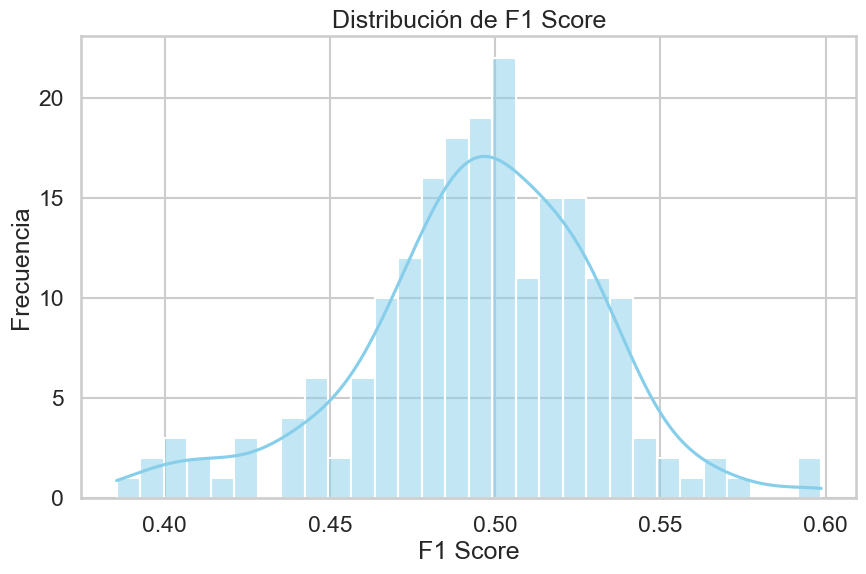

Estadísticas descriptivas del F1 Score:
count    200.000000
mean       0.495083
std        0.036182
min        0.385466
25%        0.477361
50%        0.497788
75%        0.518935
max        0.598654
Name: F1, dtype: float64


In [2]:
# Análisis de la distribución del F1 Score
plt.figure(figsize=(10,6))
sns.histplot(data['F1'], bins=30, kde=True, color='skyblue')
plt.title('Distribución de F1 Score')
plt.xlabel('F1 Score')
plt.ylabel('Frecuencia')
plt.show()

# Estadísticas descriptivas
print("Estadísticas descriptivas del F1 Score:")
print(data['F1'].describe())


In [3]:
# Si dispones de la columna 'SynFlow', analiza su distribución y correlación con F1 Score
if 'SynFlow' in data.columns:
    plt.figure(figsize=(10,6))
    sns.histplot(data['SynFlow'], bins=30, kde=True, color='lightgreen')
    plt.title('Distribución de SynFlow')
    plt.xlabel('SynFlow')
    plt.ylabel('Frecuencia')
    plt.show()
    
    # Gráfico de dispersión entre SynFlow y F1 Score
    plt.figure(figsize=(8,6))
    sns.scatterplot(x='SynFlow', y='F1', data=data, alpha=0.6)
    sns.regplot(x='SynFlow', y='F1', data=data, scatter=False, color='red')
    plt.title('Correlación entre SynFlow y F1 Score')
    plt.xlabel('SynFlow')
    plt.ylabel('F1 Score')
    plt.show()
    
    # Calcular correlación de Pearson
    from scipy.stats import pearsonr
    corr, p_value = pearsonr(data['SynFlow'], data['F1'])
    print(f"Correlación de Pearson: {corr:.4f} (p-valor: {p_value:.4f})")


C:\Users\herna\AppData\Local\Temp\ipykernel_20904\3469545538.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='tipo', data=layer_types, palette='viridis')


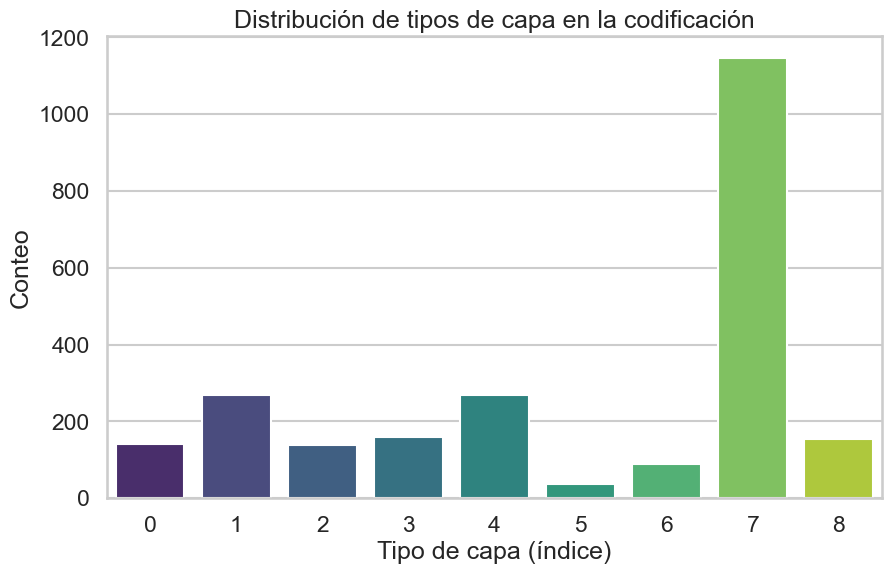

In [4]:
# Expandir la columna 'Encoded Architecture' en un DataFrame
encoded_df = pd.DataFrame(data['Encoded Architecture'].tolist())
encoded_df.columns = [f'param_{i}' for i in range(encoded_df.shape[1])]

# Ver la distribución del parámetro que representa el tipo de capa (por ejemplo, cada 4 columnas se define un layer)
layer_types = encoded_df.iloc[:, ::4]  # Tomamos cada 4 columnas
layer_types = layer_types.melt(var_name='layer', value_name='tipo')
plt.figure(figsize=(10,6))
sns.countplot(x='tipo', data=layer_types, palette='viridis')
plt.title('Distribución de tipos de capa en la codificación')
plt.xlabel('Tipo de capa (índice)')
plt.ylabel('Conteo')
plt.show()
